# Agricultural Drought Risk Assessment for non-staple crops

- A workflow from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and [DROUGHTS](https://github.com/CLIMAAX/DROUGHTS) GitHub repository.
- See our [how to use risk workflows](https://handbook.climaax.eu/notebooks/workflows_how_to.html) page for information on how to run this notebook.

An alternative risk calculation route is provided for users evaluating the risk for non-staple crops, such as fruits and vegetables. This alternative method is intended to provide a more accurate evaluation of the potential economic losses deriving from the lack of irrigation on these crops, as they usually have higher econonomic value per unit than staple crops. 

The main difference to the [other risk assessment methodology](./AGRICULTURE_DROUGHT_Risk_Assessment.ipynb) is the use of crop-specific, nationally averaged prices from [EUROSTAT](https://ec.europa.eu/eurostat/data/database?node_code=apri_ap_crpouta) as the source of value (instead of the GAEZ aggregated dataset). Otherwise, the same limitations apply.

## Load libraries

:::{admonition} Find more info about the libraries used in this workflow here
:class: hint dropdown

- [os](https://docs.python.org/3/library/os.html) - To create directories and work with files
- [zipfile](https://docs.python.org/3/library/zipfile.html) - To extract files from zipped folders.
- [pooch](https://www.fatiando.org/pooch/latest/index.html) - To download data from various repositories.
- [pyDataverse](https://pydataverse.readthedocs.io/en/latest/) - To download data from Harvard Dataverse.
- [eurostat](https://bitbucket.org/noemicazzaniga/eurostat) - Retrieve eurostat data
- [gisco_geodata](https://github.com/alecsandrei/gisco-geodata) - Access to the European Commission’s GISCO geospatial data.
- [numpy](https://numpy.org/doc/stable/index.html) - To make calculations and handle data in the form of arrays.
- [pandas](https://pandas.pydata.org/docs/index.html) - To store data in the form of DataFrames.
- [geopandas](https://geopandas.org/en/stable/index.html) - To read georeferenced files as DataFrames.
- [rasterio](https://rasterio.readthedocs.io/en/stable/) - To access and explore geospatial raster data in GeoTIFF format.
- [matplotlib](https://matplotlib.org/) and [cartopy](https://scitools.org.uk/cartopy/docs/latest/index.html) - For plotting.
:::

In [1]:
import os
import zipfile

import pooch
import pyDataverse.api
import eurostat
import gisco_geodata

import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Create the directory structure
First, we need to set up the directory structure.
The next cell will create the directory called `agriculture_workflow` in the same directory where this notebook is saved. A directory for data and one for results will also be created inside the main workflow directory to store the downloaded data and the final plots. 

In [2]:
workflow_dir = 'agriculture_workflow'

# Define directories for data and results within the previously defined workflow directory
data_dir = os.path.join(workflow_dir, 'data')
results_dir = os.path.join(workflow_dir, 'results')

os.makedirs(workflow_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

## Define the studied area

The cell below allows to retrieve the boundaries of any NUTS region the region code (in this case ES51 for Catalunya). You can look up the NUTS codes for all EU regions [here](https://ec.europa.eu/eurostat/documents/3859598/15193590/KS-GQ-22-010-EN-N.pdf) by simply searching the document for the region name.

In [3]:
gisco = gisco_geodata.NUTS()
nuts = gisco.get(
    countries=['ES51'],  # put a NUTS ID here
    nuts_level='LEVL_2',  # adjust the NUTS level to match your ID
    scale='10M',  # select data resolution (1M, 3M, 10M, 20M or 60M)
    spatial_type='RG',
    projection='4326'
)
nuts_name = '+'.join(nuts['NAME_LATN'])

print(f'Selected NUTS domain: {nuts_name}')

Selected NUTS domain: Cataluña


The code below creates the study area bounding box using the coordinates of the region. 

In some cases, it might be needed to expand the selected area through the 'scale' parameter to avoid the corners of the region being left out from the data extraction. The units of the `scale` parameter are degrees (longitude/latitude), so setting `scale=1` will increase the extraction area by approximately 100 km. A scale of 0-0.5 should be sufficient to fully cover most regions.

In [4]:
# Defining the region bounding box, scale parameter can be adjusted 
scale = 0.5
bbox = [
    nuts.total_bounds[0] - scale,
    nuts.total_bounds[1] - scale,
    nuts.total_bounds[2] + scale,
    nuts.total_bounds[3] + scale
]

## Import hazard data 

To run the risk assessment workflow you will first need to import data from the [hazard](AGRICULTURE_DROUGHT_Hazard.ipynb) workflow.

::: {warning}
The hazard assessment workflow uses Catalunya as a default region. If you want to run the risk workflow for a different region, change the selection in the [hazard](AGRICULTURE_DROUGHT_Hazard.ipynb) workflow first.
:::

Run the cell below to load data from the hazard assessment and visualise them.

In [5]:
# Load yield loss data from the .npy and .csv files produced by the hazard workflow
yield_loss_perc = np.load(f'{results_dir}/{nuts_name}_yield_loss_NUMPY.npy')
hazard_df = pd.read_csv(f'{results_dir}/{nuts_name}_yield_loss_SPREADSHEET.csv')

# Extract the lat-lon coordinates from the hazard dataframe for resampling of other fields
coords_11 = np.stack((hazard_df['lon'].to_numpy(), hazard_df['lat'].to_numpy()), axis=1)

# Reference shape of a lat-lon field
fields_shape = yield_loss_perc.shape[0:2]

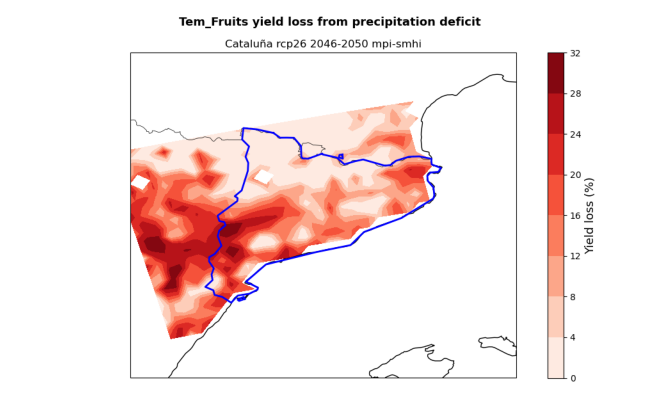

In [6]:
# Visualise the yield loss maps produced by the hazard workflow
hazard_files = [x for x in os.listdir(results_dir) if (nuts_name in x and 'yield_loss.png' in x)]

for i in hazard_files:
    img = mpimg.imread(f'{results_dir}/{i}',format='png')
    fig = plt.figure()
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    plt.imshow(img)
    plt.show()

## Download and extract Exposure data

### 1. Crops Production  

Next we will need data on crop production to calculate exposure.
Crop production [ton] data for 2020 is retrieved from the [MapSPAM repository](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/SWPENT) on Harvard Dataverse.
Data is available as global `.tif` rasters at 5 arc-min resolution for different combinations of human inputs and irrigation modes.
In this assessment, we will use data for crops grown under 'high' human inputs and 'all' irrigation modes.
46 files are downloaded for the 2020 dataset, one for each crop available on the MapSPAM repository.
The step-by-step download procedure is explained within the code below.

In [7]:
# Set up the API to retrieve the SPAM dataset from Harvard Dataverse given the DOI 
base_url = 'https://dataverse.harvard.edu/'
api = pyDataverse.api.NativeApi(base_url)

# Retrieve and display the list of available files for the SPAM dataset
dataset = api.get_dataset('doi:10.7910/DVN/SWPENT')
files_list = dataset.json()['data']['latestVersion']['files']
for file in files_list:
    print("ID {id}, Filename: {filename}".format(**file["dataFile"]))

ID 11596408, Filename: Readme_SPAM2020V2r0.txt
ID 11596409, Filename: spam2020V2r0_global_harvested_area.csv.zip
ID 11596412, Filename: spam2020V2r0_global_harvested_area.geotiff.zip
ID 11596414, Filename: spam2020V2r0_global_physical_area.csv.zip
ID 11596411, Filename: spam2020V2r0_global_physical_area.geotiff.zip
ID 11596413, Filename: spam2020V2r0_global_production.csv.zip
ID 11596407, Filename: spam2020V2r0_global_production.geotiff.zip
ID 11596410, Filename: spam2020V2r0_global_yield.csv.zip
ID 11596406, Filename: spam2020V2r0_global_yield.geotiff.zip


:::{tip}
You might be interested in other files in the SPAM directory than the production ones used in this workflow. In the list above, you can find the ID code needed to download them.
In this workflow we are using the global production GeoTIFF file and associated download ID.
:::

In [8]:
# Specify path where the downloaded zip file will be saved
spam_path = os.path.join(data_dir, 'spam_prod_geotiff.zip')

# Output folder name, must match structure in downloaded zip file
spam_folder = os.path.join(data_dir, 'spam2020V2r0_global_production')

In [9]:
# Download the dataset for crops production given the ID
download_id = '11596407'

data_api = pyDataverse.api.DataAccessApi(base_url)
response = data_api.get_datafile(download_id, is_pid=False)
with open(spam_path, "wb") as f:
    f.write(response.content)

# Extract the SPAM files, select the 'all' irrigation files only
with zipfile.ZipFile(spam_path, 'r') as zObject:
    selected_files = [x for x in zObject.namelist() if '_A.tif' in x]
    zObject.extractall(path=data_dir, members=selected_files)

To select the SPAM files for the crops you are interested in, you will have to correctly specify their name.
Run the cell below to print the list of available crops.
In the SPAM files, crops are identified by a 4-letter acronym in capital letters.

In [10]:
print(", ".join(f.split("_")[-2] for f in selected_files))

BANA, BARL, BEAN, CASS, CHIC, CITR, CNUT, COCO, COFF, COTT, COWP, GROU, LENT, MAIZ, MILL, OCER, OFIB, OILP, ONIO, OOIL, OPUL, ORTS, PIGE, PLNT, PMIL, POTA, RAPE, RCOF, REST, RICE, RUBB, SESA, SORG, SOYB, SUGB, SUGC, SUNF, SWPO, TEAS, TEMF, TOBA, TOMA, TROF, VEGE, WHEA, YAMS


First, we retrieve the production (ton) information from MapSPAM for relevant non-staple crop categories.

In [11]:
# Codes for extraction of MapSPAM file
spam_list = ['TEMF', 'CITR', 'VEGE']

# Find file and extract data for the studied region
spam_folder = os.path.join(data_dir, 'spam2020V2r0_global_production')
crops_spam = hazard_df[["lat", "lon"]].copy().set_index(["lat", "lon"])
for a, crop in enumerate(spam_list):
    for i in os.listdir(spam_folder):
        if crop in i:
            raster_path = os.path.join(spam_folder, i)
            break
    with rasterio.open(raster_path) as src:
        crops_spam[crop] = [x[0] for x in src.sample(coords_11)]

crops_spam[crops_spam < 0] = np.nan

### 2. Crops value (EUR) from EUROSTAT

In [12]:
# Code of dataset from EUROSTAT listing annual crop prices by country
code = 'apri_ap_crpouta'

# Get dictionary of country IDs for users to choose from
eurostat.get_dic(code,'geo', full=False)

[('BE', 'Belgium'),
 ('BG', 'Bulgaria'),
 ('CZ', 'Czechia'),
 ('DK', 'Denmark'),
 ('DE', 'Germany'),
 ('EE', 'Estonia'),
 ('IE', 'Ireland'),
 ('EL', 'Greece'),
 ('ES', 'Spain'),
 ('FR', 'France'),
 ('HR', 'Croatia'),
 ('IT', 'Italy'),
 ('CY', 'Cyprus'),
 ('LV', 'Latvia'),
 ('LT', 'Lithuania'),
 ('LU', 'Luxembourg'),
 ('HU', 'Hungary'),
 ('MT', 'Malta'),
 ('NL', 'Netherlands'),
 ('AT', 'Austria'),
 ('PL', 'Poland'),
 ('PT', 'Portugal'),
 ('RO', 'Romania'),
 ('SI', 'Slovenia'),
 ('SK', 'Slovakia'),
 ('FI', 'Finland'),
 ('SE', 'Sweden'),
 ('UK', 'United Kingdom'),
 ('XK', 'Kosovo*')]

Crop values from EUROSTAT are used to get an estimate of the current crop market prices. The default is an average price for 2015-2024, but the user can customise this range. 

:::{tip}
If data is not available for your country, try to consult national datasets to retrieve this information. 
:::

In [13]:
# Set dataset filters for time, country and currency

# Select country of studied region using ID in dictionary above
country = 'ES'

# Select time period for reference crop values (latest data are from 2024).
start_year = 2015
end_year = 2024

# Filter
my_filter_pars = {
    'startPeriod':start_year,
    'endPeriod': end_year,
    'geo':country,
    'currency':'EUR'
}

# Retrieve data from eurostat
data = eurostat.get_data_df(code, filter_pars=my_filter_pars)
# Create dictionary of available crops for the selected country
dic_crops = eurostat.get_dic(code,'prod_veg',frmt='df', full=False)
# Create new column in the downloaded dataset storing the crop name from dictionary
data['name_crop'] = data['prod_veg'].map(dic_crops.set_index('val')['descr'])
# Calculate mean price for all available crops for the whole selected period
data['crop_mean_value']=data.iloc[:,4:-1].mean(numeric_only=True,axis=1)

:::{important}

Differently from MapSPAM (used for the staple crops), EUROSTAT stores data on crop prices for individual crops, not for categories. In the example below, we show how to get values for peach and apple, both belonging to the "temperate fruit" category but having different market prices.

:::

## Download and extract Vulnerability data - Irrigation availability

Next we will need data on cropland full-irrigation availability to define vulnerability.
The dataset is also sourced from GAEZ v5 ([Share of irrigated land](https://data.apps.fao.org/catalog//iso/5e11e7c5-9088-4f1a-80df-04ef026bd726)).
The dataset contains the percentage of cropland area under irrigation in a 30 arc-second grid-cell for year 2015.

In [14]:
irr_avail_path = os.path.join(data_dir, 'GAEZ-V5.LR-IRR.tif')

pooch.retrieve(
    url='https://storage.googleapis.com/fao-gismgr-gaez-v5-data/DATA/GAEZ-V5/MAP/GAEZ-V5.LR-IRR.tif',
    known_hash='28ab7ebd65e037bb7f5440b3a9ad4f803d9d2076c3ca6907d151a02cc56dadde',
    path=os.path.dirname(irr_avail_path),
    fname=os.path.basename(irr_avail_path)
)

'/Users/ecm5975/CLIMAAX/DROUGHTS/02_agriculture_drought/agriculture_workflow/data/GAEZ-V5.LR-IRR.tif'

The cell below extracts irrigation availability data from the raster and stores them as an array.

In [15]:
with rasterio.open(irr_avail_path) as src:
    irr_share = np.asarray([x[0] for x in src.sample(coords_11)], dtype=np.float64)

irr_share = irr_share.reshape(fields_shape)

## Data processing

Select the studied crop from a list of available options form MapSPAM and EUROSTAT. 

:::{important}

Aside from a few exceptions, fruits, citrus and vegetables are grouped in broad categories in MapSPAM and not available individually. The respective codes needed to select the files for these categories are:

- TEMF = temperate fruits
- CITR = citrus
- VEGE = vegetables not individually listed

Please run this part of the workflow for **one** of these categories each time.
:::

The cells below provide an example on how to run the workflow for temperate (i.e., non-tropical) fruits. This assumes that the hazard workflow has already been run for the same crop category.  

In [16]:
# Select spam category (see info box above)
spam_selection = 'TEMF'

# Select studied crops, need to spell the name in english
crops = ['peach', 'apple']

# Display selection
data_crop = data[data['name_crop'].str.contains('|'.join(crops), case=False, na=False)]
data_crop

,freq,currency,prod_veg,geo\TIME_PERIOD,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,name_crop,crop_mean_value
57,A,EUR,06110000,ES,37.73,43.02,43.82,54.07,43.38,49.90,55.32,49.95,66.17,62.24,Dessert apples: all varieties - prices per 100 kg,50.560
59,A,EUR,06130000,ES,56.10,59.83,50.29,73.53,50.04,77.68,81.94,91.26,79.54,77.51,Peaches: all varieties - prices per 100 kg,69.772


:::{tip}
If the crop search did not result in the expected crops, inspect the table from EUROSTAT in the `data` variable and revise the names given in `crops` to better match those in the table (column `name_crop`).
:::

When selecting multiple crops in the list `crops` above, the yield loss data imported from the hazard assessment earlier (`yield_loss_perc`) must either:

1. only contain values for a single crop from the [crop table](./crop_table.ipynb) (these values are then used for all crops selected here) *or*
2. the number of crops in the yield loss data must match the number of crops specified here exactly (crop entries are then matched by position).

**Example (option 1):** Two crops are specified here in variable `crops`: peach and apple. Both are temperate fruit, so the hazard workflow is run only for temperate fruits. This setup corresponds to the first option listed above. The yield loss percentages for temperate fruits from the hazard assessment are used in the calculation for both fruits and two output plots (one for peach, one for apple) are produced at the end of this notebook.

**Example (option 2):** If the crop table was extended with individual entries for peach and apple and the hazard assessment run for both, the second option would apply. Because there are two crops in each dataset, the datasets can be matched by position. The crops in variable `crops` here must be listed in the same order as they were processed in the hazard assessment notebook (variable `crop_list` there) for the matching to provide correct results.

We verify that the datasets are compatible:

In [17]:
assert yield_loss_perc.shape[2] == 1 or len(crops) == yield_loss_perc.shape[2], (
    f"Mismatch: {len(crops)} crops selected here but {yield_loss_perc.shape[2]} crops in yield loss data from hazard assessment"
)

Calculate the revenue loss deriving from growing the selected crops under rainfed conditions rather than irrigated. 

In [18]:
# For individual crops within one group
crop_revenue_single = pd.DataFrame(index=crops_spam.index)

for single_crop in crops:
    single_crop_value = data_crop[data_crop['name_crop'].str.contains(
            single_crop, case=False, na=False)]['crop_mean_value'].mean()
    # Price is per 100 kg, multiply by 10 to get tons
    crop_revenue_single[single_crop] = crops_spam[spam_selection] * single_crop_value * 10

crop_revenue_aggregated = crop_revenue_single.mean(axis=1)

:::{tip}

Some crops have more than one entry in the EUROSTAT table (e.g., strawberries in the open and strawberries under glass). The calculation can be performed for an average price of all crops selected from EUROSTAT (aggregated) or for each of them individually (single).
:::

In [19]:
# Select which price calculation to use (single or aggregated)
to_plot = crop_revenue_single

# Reshape the crop_revenue_* data to allow for combination with yield_loss_perc
crop_revenue_as_fields = to_plot.to_numpy().reshape((*fields_shape, -1))
if crop_revenue_as_fields.shape[2] == 1:
    # Repeat the aggregated revenue results for each crop so individual plots work
    crop_revenue_as_fields = np.tile(crop_revenue_as_fields, len(crops))

# Determine the revenue loss
revenue_loss_euro = crop_revenue_as_fields * yield_loss_perc / 100

# Scale loss as in the notebook for staple crop (k€)
revenue_loss_euro = revenue_loss_euro / 1000.

## Plotting the results

The cell below allows to plot the revenue loss results for the studied region. The red shading shows the revenue loss per grid-cell for the studied crops deriving from the absence of irrigation. The hatching shows different levels of irrigation infrastructure availability within the region, highlighting areas of different vulnerability.

The resulting plot states the crop, RCP scenario and reference period used in the assessment. The plotting procedure steps are described within the cell.

:::{tip}

Use the `zoom` parameter to set how much you would like the final plot to be zoomed-out from the region boundaries (0=no zoom out, 1=100 km).
Here a zoom of 0.5 degrees (50 km) is used.
:::

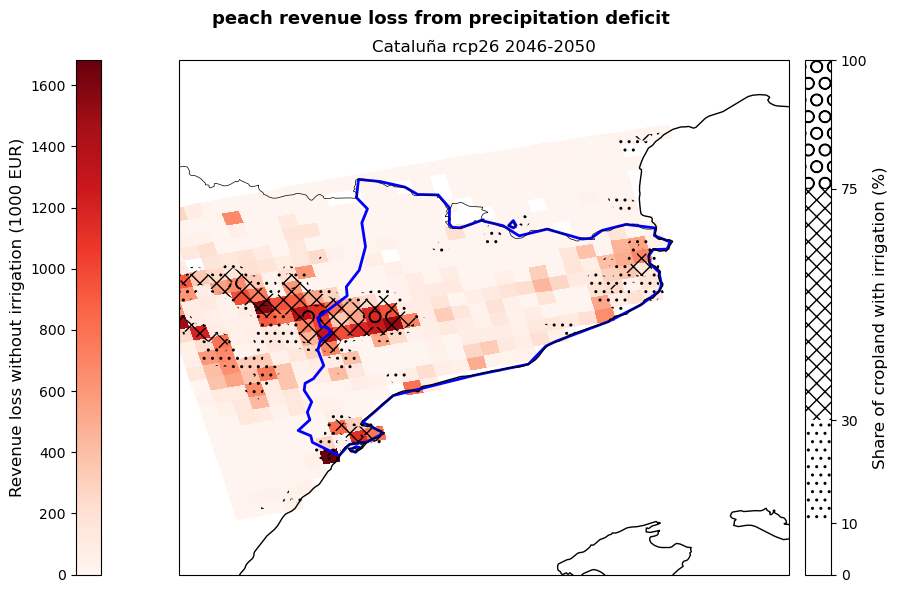

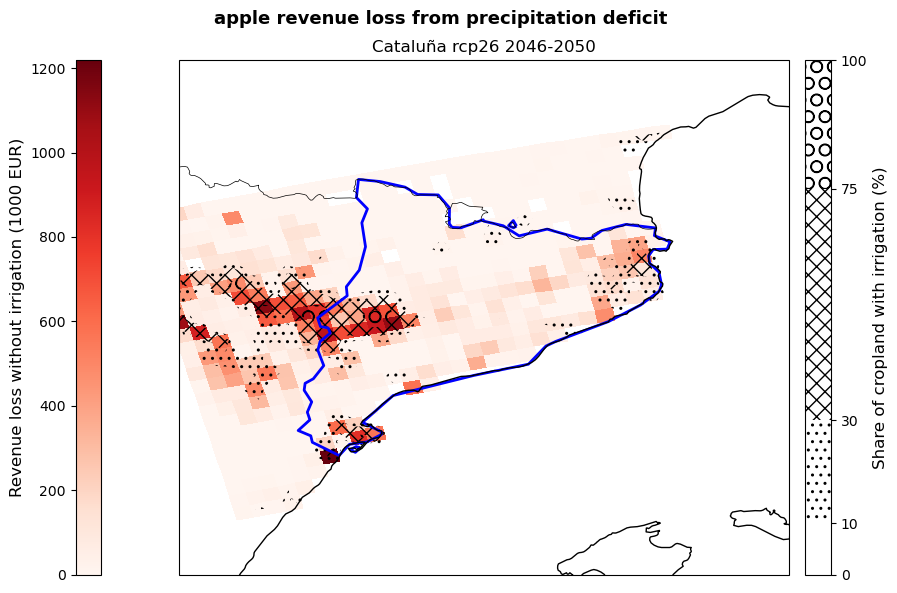

In [20]:
rcp = hazard_df['rcp'][0]  # identify the climate projection
ystart = hazard_df['start_year'][0]  # identify the projection start year
yend = hazard_df['end_year'][0]  # identify the projection end year

# Zoom parameter
zoom = 0.5

# Define the longitude and latitude coordinates
lon_plot = hazard_df['lon'].to_numpy().reshape(fields_shape)
lat_plot = hazard_df['lat'].to_numpy().reshape(fields_shape)

# Define irrigation vulnerability levels
irr_levels = np.array([0, 10, 30, 75, 100])

for a, crop in enumerate(crops):
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([bbox[0] - zoom, bbox[2] + zoom, bbox[1] - zoom, bbox[3] + zoom], crs=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Plot the revenue loss
    revenue_map = ax.pcolormesh(lon_plot, lat_plot, revenue_loss_euro[:,:,a],
            cmap="Reds", transform=ccrs.PlateCarree(), zorder=1)
    revenue_cbar = fig.colorbar(revenue_map, ax=ax, orientation='vertical', location='left', pad=0.02)
    revenue_cbar.set_label('Revenue loss without irrigation (1000 EUR)', fontsize=12)

    # Plot the irrigation availability
    irr_map = ax.contourf(lon_plot, lat_plot, irr_share, colors='none', hatches=['', '..', 'xx', 'O'], 
                          transform=ccrs.PlateCarree(), levels=irr_levels, zorder=1)
    irr_cbar = fig.colorbar(irr_map, ax=ax, orientation='vertical', location='right', pad=0.02, spacing='proportional')
    irr_cbar.set_label('Share of cropland with irrigation (%)', fontsize=12)

    # Add shapefile data for region boundaries
    nuts.plot(ax=ax, edgecolor='b', facecolor='none', linewidth=2, aspect=None)

    # Titles
    plt.suptitle(f"{crop} revenue loss from precipitation deficit", fontsize=13, fontweight='bold')
    plt.title(f"{nuts_name} {rcp} {ystart}-{yend}")

    # Layout and save
    plt.tight_layout()
    plt.savefig(f'{results_dir}/{nuts_name}_{spam_list[a]}_revenue_loss_EUR.png')
    plt.show()

The figures produced show the potential revenue losses from irrigation deficit in the studied region for the selected crops, emission scenario and period. Losses are expressed by the red shading and represent the 'lost opportunity cost' in thousands euros if crops are grown under non-irrigated conditions. The hatches show the share of cropland in each grid-point with irrigation systems already implemented in 2015 and serves as an indicator of vulnerability to rainfall scarcity.

These maps can be used by demonstrators to understand which areas of their region are expected to suffer the greatest losses, as well as which crops will be the most impacted by the absence of irrigation. This allows them to target adaptation efforts, such as the improvement of the current irrigation network, in the most affected and vulnerable areas favouring a cost-effective use of resources. At the same time, the map provides a snap-shot of a potential future growing season that can be used to guide cropland expansion towards areas and products less affected by water stress.

## Conclusions

Now that you were able to calculate damage maps based on yield loss maps and view the results, you can consider the following questions:

- How accurate do you think this result is for your local context? 
- What additional information are you missing that could make this assessment more accurate?
- What can you already learn from these maps of potential yield and revenue losses?

:::{important}

In this risk workflow we learned:

- how to access and use global datasets on non-staple crop production and irrigation availability.
- how to combine data on potential yield losses to the current crop production to estimate future potential revenue losses.
- how to use maps of irrigation distribution as a proxy for water-stress vulnerability.
:::

## Contributors

Euro-Mediterranean Center on Climate Change (CMCC), Italy.

Author of the workflow: Andrea Rivosecchi